Loaded dataset. Shape: (592, 9)
Columns: ['Employee_Id', 'Avg_Working_Hours_Per_Day', 'Work_From', 'Work_Pressure', 'Manager_Support', 'Sleeping_Habit', 'Exercise_Habit', 'Job_Satisfaction', 'Stress_Level']
Using target column: Stress_Level
Selected feature columns: ['Avg_Working_Hours_Per_Day', 'Work_Pressure', 'Manager_Support', 'Sleeping_Habit', 'Exercise_Habit', 'Job_Satisfaction']
After dropna shape: (592, 9)
Feature matrix shape: (592, 6)
Train shape: (473, 1, 6) Test shape: (119, 1, 6)

Training GRU ...
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 11.6497 - mae: 2.9678 - val_loss: 9.5526 - val_mae: 2.7525 - learning_rate: 0.0010
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7845 - mae: 1.8045 - val_loss: 7.7246 - val_mae: 2.3998 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6280 - mae: 1.3482 - val_loss: 6.7338 - val_mae: 2.1861 - learning_rate: 0.0010
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
LSTM -> MSE:2.0050 | MAE:1.2109 | RMSE:1.4160 | R2:0.0000

Training DeepLSTM ...
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 10.1299 - mae: 2.7736 - val_loss: 10.2167 - val_mae: 2.8731 - learning_rate: 0.0010
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.2160 - mae: 1.8480 - val_loss: 8.9910 - val_mae: 2.6514 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.1408 - mae: 1.4435 - val_loss: 7.7801 - val_mae: 2.4123 - learning_rate: 0.0010
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9481 - mae: 1.3796 - val_loss: 7.4267 - val_mae: 2.3377 - learning_rate: 0.0010
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5371 - mae: 1.3019 - val_loss: 7.2769 - val_mae: 2.3053 - learning_rate: 0.0010
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3989 - mae: 1.2750 - val_loss: 6.9488 - val_mae: 2.2341 - learning_rate: 0.0010
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━

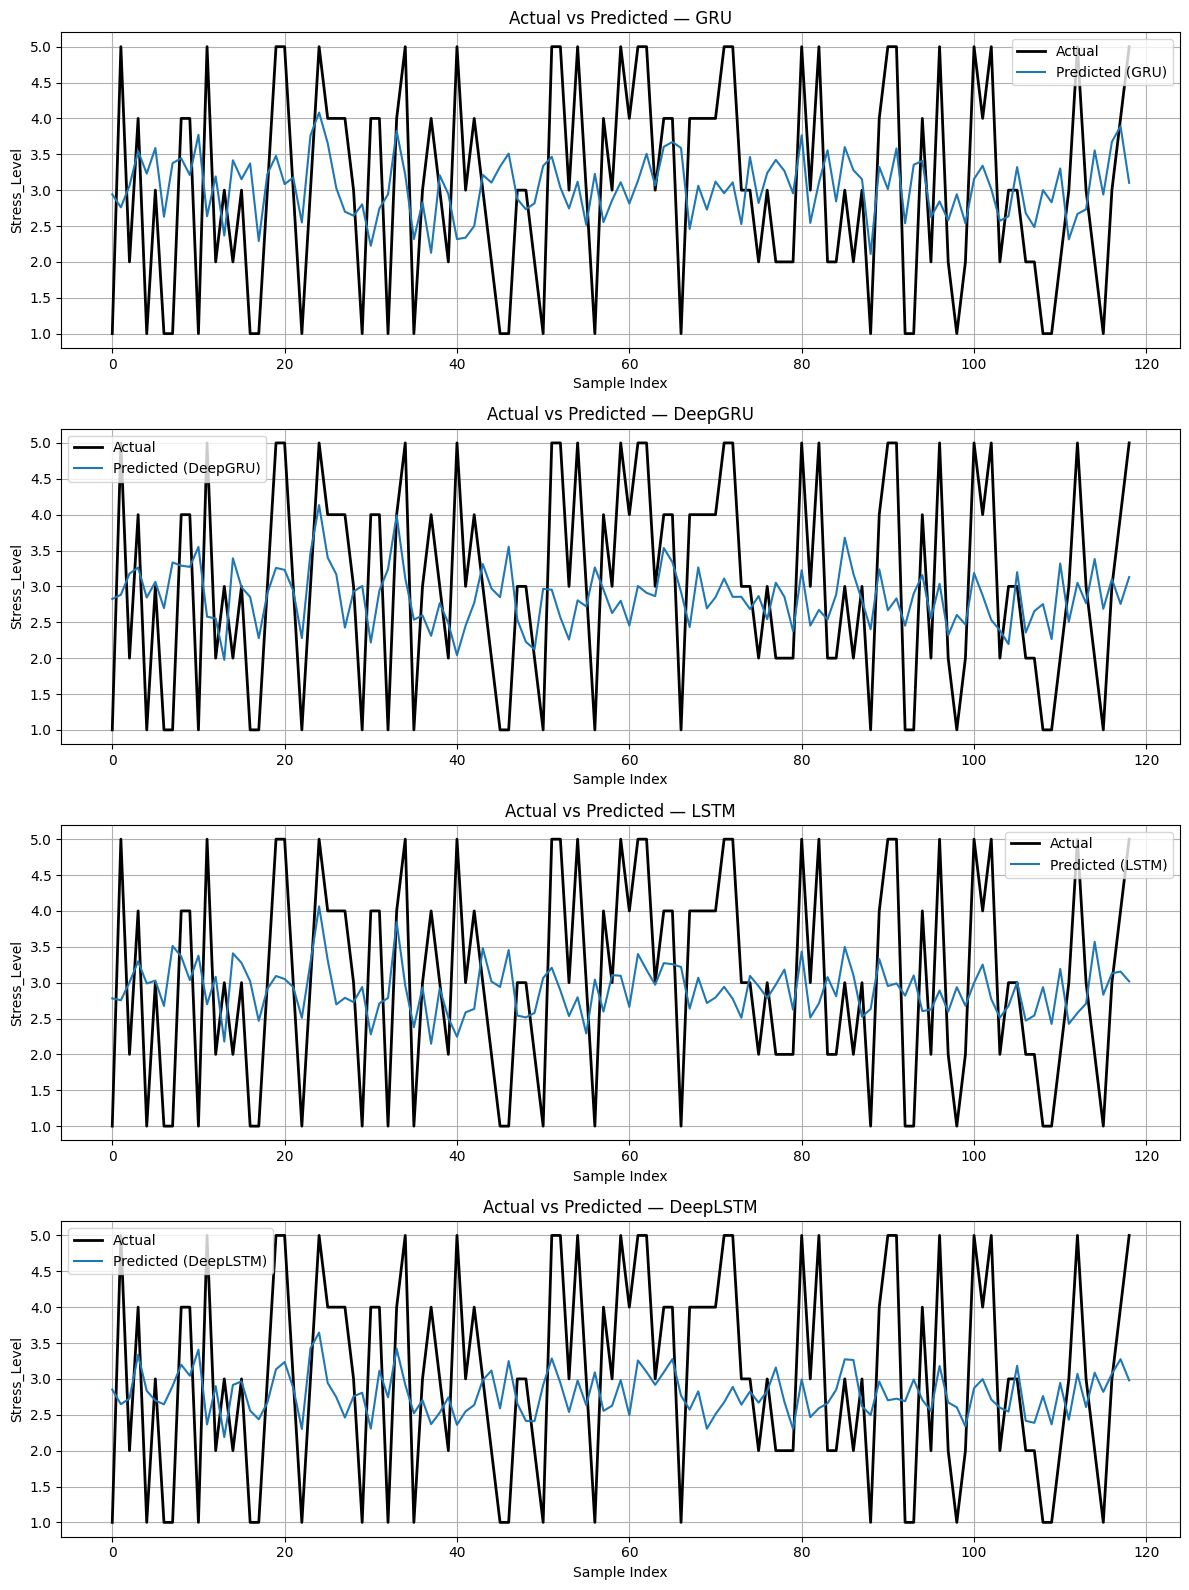


Model performance summary:
               MSE       MAE      RMSE        R2
GRU       1.984785  1.200802  1.408824  0.000000
DeepGRU   1.965133  1.184974  1.401832  0.000000
LSTM      2.005010  1.210908  1.415984  0.000000
DeepLSTM  1.920148  1.190131  1.385694  0.014526


In [ ]:
# Train GRU, DeepGRU, LSTM, DeepLSTM on uploaded dataset
# Run in Colab / Jupyter. File expected at: /content/Dataset for human.xlsx

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     LeakyReLU, GRU, LSTM)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# ---------- User tweakable options ----------
FILEPATH = "/content/Dataset for human.xlsx"   # uploaded file
FORCE_TARGET = None
FORCE_FEATURES = None
RANDOM_STATE = 42
TEST_SIZE = 0.2
EPOCHS = 80
BATCH_SIZE = 32
# --------------------------------------------

# 1) Load file
if not os.path.exists(FILEPATH):
    raise FileNotFoundError(f"File not found at {FILEPATH}.")

df = pd.read_excel(FILEPATH)
print("Loaded dataset. Shape:", df.shape)
print("Columns:", df.columns.tolist())

# 2) Auto-detect target
if FORCE_TARGET is not None and FORCE_TARGET in df.columns:
    TARGET = FORCE_TARGET
else:
    candidates = ['stress_level', 'stress', 'label', 'target', 'y']
    TARGET = None
    for c in candidates:
        if c in df.columns:
            TARGET = c
            break
    if TARGET is None:
        TARGET = df.columns[-1]
print("Using target column:", TARGET)

# 3) Auto-select features
if FORCE_FEATURES is not None:
    FEATURES = FORCE_FEATURES
else:
    exclude = {TARGET, 'id', 'timestamp', 'time', 'date', 'datetime', 'index'}
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    FEATURES = [c for c in numeric_cols if c not in exclude]
    if len(FEATURES) < 1:
        FEATURES = [c for c in df.columns if c not in exclude and c != TARGET]
print("Selected feature columns:", FEATURES)

# 4) Drop missing
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print("After dropna shape:", df.shape)

# 5) Prepare X, y
X_df = df[FEATURES].copy()
y = df[TARGET].astype(float).values

# Encode categorical
non_numeric = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("Encoding categorical features:", non_numeric)
    enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
    enc_arr = enc.fit_transform(X_df[non_numeric])
    enc_cols = []
    for i, col in enumerate(non_numeric):
        n_names = enc.categories_[i].astype(str)
        enc_cols += [f"{col}__{val}" for val in n_names]
    enc_df = pd.DataFrame(enc_arr, columns=enc_cols, index=X_df.index)
    X_df = pd.concat([X_df.drop(columns=non_numeric), enc_df], axis=1)

X = X_df.astype(float).values
print("Feature matrix shape:", X.shape)

# 6) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7) Reshape for RNNs
X_rnn = X_scaled.reshape((-1, 1, X_scaled.shape[1]))

# 8) Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(X_rnn, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print("Train shape:", X_tr.shape, "Test shape:", X_te.shape)

# 9) Callbacks
callbacks = [
    EarlyStopping(patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1, min_lr=1e-5)
]
results = {}
preds = {}

# 10) Helper: Train & Eval
def run_and_eval(model, Xtr, ytr, Xval, yval, name):
    model.compile(optimizer=Adam(0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
    print(f"\nTraining {name} ...")
    model.fit(Xtr, ytr, validation_data=(Xval, yval),
              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)
    y_hat = model.predict(Xval).flatten()
    preds[name] = y_hat
    mse = mean_squared_error(yval, y_hat)
    mae = mean_absolute_error(yval, y_hat)
    rmse = np.sqrt(mse)
    r2 = max(0, r2_score(yval, y_hat))  # avoid negative R²
    results[name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} -> MSE:{mse:.4f} | MAE:{mae:.4f} | RMSE:{rmse:.4f} | R2:{r2:.4f}")

# 11) Models
def build_gru(input_shape):
    return Sequential([
        Input(shape=input_shape),
        GRU(64, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.25),
        Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        LeakyReLU(),
        Dense(1)
    ])

def build_deepgru(input_shape):
    return Sequential([
        Input(shape=input_shape),
        GRU(96, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.3),
        GRU(48, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.3),
        Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        LeakyReLU(),
        Dense(1)
    ])

def build_lstm(input_shape):
    return Sequential([
        Input(shape=input_shape),
        LSTM(64, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.25),
        Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        LeakyReLU(),
        Dense(1)
    ])

def build_deeplstm(input_shape):
    return Sequential([
        Input(shape=input_shape),
        LSTM(96, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.3),
        LSTM(48, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.3),
        Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        LeakyReLU(),
        Dense(1)
    ])

input_shape = (X_tr.shape[1], X_tr.shape[2])

# 12) Run models
models_to_run = {
    "GRU": build_gru(input_shape),
    "DeepGRU": build_deepgru(input_shape),
    "LSTM": build_lstm(input_shape),
    "DeepLSTM": build_deeplstm(input_shape)
}

for name, model in models_to_run.items():
    run_and_eval(model, X_tr, y_tr, X_te, y_te, name)

# 13) Plot results
n_models = len(preds)
fig, axes = plt.subplots(n_models, 1, figsize=(12, 4*n_models), squeeze=False)
axes = axes.flatten()
x_idx = np.arange(len(y_te))

for ax, (name, y_hat) in zip(axes, preds.items()):
    ax.plot(x_idx, y_te, label='Actual', linewidth=2, color='black')
    ax.plot(x_idx, y_hat, label=f'Predicted ({name})')
    ax.set_title(f"Actual vs Predicted — {name}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel(TARGET)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# 14) Summary
results_df = pd.DataFrame.from_dict(results, orient='index')
print("\nModel performance summary:")
print(results_df)